***To Preserve the outputs, we actually copy pasted the outputs as commets """like this is a comment""""***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# ***GPU Data merger***

In [ ]:
!pip install cudf-cu12 dask-cudf-cu12 --extra-index-url=https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 99.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 MB 40.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cuda-nvrtc-cu12
    Found existing installation: nvidia-cuda-nvrtc-cu12 12.6.77
    Uninstalling nvidia-cuda-nvrtc-cu12-12.6.77:
      Successfully uninstalled nvidia-cuda-nvrtc-cu12-12.6.77
  Attempting uninstall: nvidia-cuda-nvcc-cu12
    Found existing installation: nvidia-cuda-nvcc-cu12 12.5.82
    Uninstalling nvidia-cuda-nvcc-cu12-12.5.82:
      Successfully uninstalled nvidia-cuda-nvcc-cu12-12.5.82
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.9.0+cu126 requires nvidia-cuda-nvrtc-cu12==12.6.77; platform_system == "Linux", but you have nvidia-cuda-nvrtc-cu12 12.9.86 which is incompatible.

In [ ]:
import dask_cudf
import cudf
import pandas as pd
import glob
import os

# 1. Setup Paths
file_pattern = "/content/drive/MyDrive/DCU/Data_Viz/Dataset/*.csv"
files = glob.glob(file_pattern)

if not files:
    raise FileNotFoundError("No CSV files found! Check your path.")

print(f"Found {len(files)} files. Scanning headers to find common columns...")

# 2. Auto-Detect Common Columns (intersection = only keep columns present in ALL files)
common_columns = None
for f in files:
    cols = set(pd.read_csv(f, nrows=0).columns)
    if common_columns is None:
        common_columns = cols
    else:
        common_columns = common_columns.intersection(cols)

use_cols = list(common_columns)
print(f"Identified {len(use_cols)} common columns: {use_cols}")

# 3. Dtypes only for columns that actually exist
desired_dtypes = {
    "number": "object",
    "callsign": "object",
    "aircraft_uid": "object",
    "typecode": "object",
}
final_dtypes = {k: v for k, v in desired_dtypes.items() if k in use_cols}

# 4. Read CSVs on GPU (NO assume_missing)
print("Reading data with dask_cudf...")
df = dask_cudf.read_csv(
    file_pattern,
    usecols=use_cols,    # ignore all non-common columns
    dtype=final_dtypes,  # only set dtypes for columns that are present
    # no assume_missing here, cuDF handles nulls directly
)

# 5. Optional: normalize some critical columns as strings (avoids parquet type issues)
def clean_partitions(partition):
    for col, dt in final_dtypes.items():
        if col in partition.columns:
            partition[col] = partition[col].astype("object")
    return partition

df = df.map_partitions(clean_partitions)
df = df.reset_index(drop=True)

this_cells_output = """Found 24 files. Scanning headers to find common columns...
Identified 14 common columns: ['number', 'origin', 'callsign', 'latitude_1', 'latitude_2', 'day', 'altitude_1', 'destination', 'longitude_2', 'altitude_2', 'longitude_1', 'typecode', 'firstseen', 'lastseen']
Reading data with dask_cudf...
"""

Found 24 files. Scanning headers to find common columns...
Identified 14 common columns: ['number', 'origin', 'callsign', 'latitude_1', 'latitude_2', 'day', 'altitude_1', 'destination', 'longitude_2', 'altitude_2', 'longitude_1', 'typecode', 'firstseen', 'lastseen']
Reading data with dask_cudf...


In [ ]:
import shutil
import os

# 6. Write to LOCAL Colab storage first (Not Drive)
# This uses the high-speed SSD of the Colab VM
local_output_path = "/content/merged_airtraffic_data.parquet"

print(f"Writing {df.npartitions} partitions to LOCAL storage ({local_output_path})...")

# If the folder exists from a previous run, remove it to ensure a fresh write
if os.path.exists(local_output_path):
    shutil.rmtree(local_output_path)

df.to_parquet(
    local_output_path,
    compression="snappy",
    write_index=False
)

# 7. Verify the local write
generated_files = glob.glob(os.path.join(local_output_path, "*.parquet"))
print(f"✅ Success! Generated {len(generated_files)} parquet partition files locally.")

# 8. Copy to Google Drive safely
drive_dest_path = "/content/drive/MyDrive/DCU/Data_Viz/merged_airtraffic_data_new_1.parquet"

print(f"Copying data to Google Drive: {drive_dest_path}...")
print("This may take a minute...")

# Remove destination if it exists to avoid conflicts
if os.path.exists(drive_dest_path):
    shutil.rmtree(drive_dest_path)

# Copy the entire folder
shutil.copytree(local_output_path, drive_dest_path)

print("🎉 Copy complete! All files should now be safe in your Drive.")

this_cells_output = """Writing 56 partitions to LOCAL storage (/content/merged_airtraffic_data.parquet)...
✅ Success! Generated 56 parquet partition files locally.
Copying data to Google Drive: /content/drive/MyDrive/DCU/Data_Viz/merged_airtraffic_data_new_1.parquet...
This may take a minute...
🎉 Copy complete! All files should now be safe in your Drive.
 """

Writing 56 partitions to LOCAL storage (/content/merged_airtraffic_data.parquet)...
✅ Success! Generated 56 parquet partition files locally.
Copying data to Google Drive: /content/drive/MyDrive/DCU/Data_Viz/merged_airtraffic_data_new_1.parquet...
This may take a minute...
🎉 Copy complete! All files should now be safe in your Drive.


# ***JUST CHECKING***

In [ ]:

# Paths
csv_pattern = "/content/drive/MyDrive/DCU/Data_Viz/Dataset/*.csv"
parquet_folder = "/content/drive/MyDrive/DCU/Data_Viz/merged_airtraffic_data_new_1.parquet"
print("Starting Integrity Check...")

# We use only 1 column to make counting super fast
print("Counting raw CSV rows (this might take a minute)...")
csv_df = dask_cudf.read_csv(csv_pattern, usecols=['callsign'])
csv_count = csv_df.shape[0].compute()
print(f"Original CSV Row Count: {csv_count:,}")

# Count Parquet Rows (The Destination)
print("Counting Parquet rows...")
parquet_df = dask_cudf.read_parquet(parquet_folder, columns=['callsign'])
parquet_count = parquet_df.shape[0].compute()
print(f"Merged Parquet Row Count: {parquet_count:,}")

# Compare
diff = csv_count - parquet_count

print("-" * 30)
if diff == 0:
    print("✅ PERFECT MATCH! No data was lost.")
    print(f"Compressed 11GB down to optimal size with {csv_count:,} rows.")
else:
    print(f"❌ MISMATCH. Difference of {diff:,} rows.")
    print("If the difference is small, it might be malformed lines in the CSVs dropped automatically.")
print("-" * 30)

cell_putput = """Starting Integrity Check...
Counting raw CSV rows (this might take a minute)...
Original CSV Row Count: 53,484,007
Counting Parquet rows...
Merged Parquet Row Count: 53,484,007
------------------------------
✅ PERFECT MATCH! No data was lost.
Compressed 11GB down to optimal size with 53,484,007 rows.
------------------------------
"""

Starting Integrity Check...
Counting raw CSV rows (this might take a minute)...
Original CSV Row Count: 53,484,007
Counting Parquet rows...
Merged Parquet Row Count: 53,484,007
------------------------------
✅ PERFECT MATCH! No data was lost.
Compressed 11GB down to optimal size with 53,484,007 rows.
------------------------------


# ***ACTUAL START***

# ***Start PreProcessing***

In [ ]:
import dask.dataframe as dd                                            # CPU Dask
import cudf                                                            # GPU DataFrame
import pandas as pd
import numpy as np
path = "/content/drive/MyDrive/DCU/Data_Viz/merged_airtraffic_data_new_1.parquet"

# Define what are the columns
columns_to_select = [
    'origin', 'destination', 'firstseen', 'lastseen', 'day',
    'callsign', 'typecode'
]

print("Lazy Loading Data (Hybrid Strategy: CPU Clean -> GPU Compute)...")

# READ WITH CPU (PyArrow) because it is robust against schema issues.
df_cpu = dd.read_parquet(
    path,
    columns=columns_to_select,
    engine="pyarrow"
)

# 4. DEFINE CLEANING LOGIC PROBELMS BEFORE WE ACTUALLY SATRT THE ACTUAL PREPARATION
def clean_and_move_to_gpu(pdf):

    # Convert to UTC/GMT and strip timezone info
    date_cols = ['day', 'firstseen', 'lastseen']
    for col in date_cols:
        if col in pdf.columns:
                                                                       # utc=True forces everything to GMT.
                                                                       # .tz_convert(None) strips the timezone info so it's GPU-compatible.
            pdf[col] = pd.to_datetime(pdf[col], errors='coerce', utc=True).dt.tz_convert(None)


    if 'day' in pdf.columns:
        pdf['day'] = pdf['day'].dt.normalize()

    # Move to GPU
    return cudf.from_pandas(pdf)

# TRANSFORMATION
print("Building transformation graph...")
meta_template = clean_and_move_to_gpu(df_cpu.head(5, compute=True))    # Compute small sample for meta
df_gpu = df_cpu.map_partitions(clean_and_move_to_gpu, meta=meta_template)

# 6. Filter Lazy
df_gpu = df_gpu.dropna(subset=['origin', 'day'])

print("Transformation graph built. Data is NOT in RAM yet.")

cell_output = """Lazy Loading Data (Hybrid Strategy: CPU Clean -> GPU Compute)...
Building transformation graph...
Transformation graph built. Data is NOT in RAM yet.
"""

Lazy Loading Data (Hybrid Strategy: CPU Clean -> GPU Compute)...
Building transformation graph...
Transformation graph built. Data is NOT in RAM yet.


In [ ]:
print("\nTop 5 rows of cleaned data:")
print(df_gpu.head())

print("\nAggregating counts (Heavy GPU work)")
counts = df_gpu['origin'].value_counts().head(10)
print(counts.to_pandas())

print("\nDiagnostic Checks")

print("Counting missing values per column")
missing_counts = df_gpu.isnull().sum().compute()
print(missing_counts)

# Check Final Shape
print("\nCalculating final shape")
num_rows = df_gpu.shape[0].compute()
num_cols = df_gpu.shape[1]
print(f"Final Data Shape: ({num_rows}, {num_cols})")

cell_output = """
Top 5 rows of cleaned data:
  origin destination           firstseen            lastseen        day  \
0   YMML        LFPG 2018-12-31 00:43:16 2019-01-01 04:56:29 2019-01-01
1   YMML        LEBL 2018-12-31 00:53:08 2019-01-01 06:01:42 2019-01-01
2   YSSY        EDDF 2018-12-31 01:05:29 2019-01-01 04:09:29 2019-01-01
3   LEMD        LEMD 2018-12-31 01:07:21 2019-01-01 03:32:59 2019-01-01
4   YSSY        LFPG 2018-12-31 01:18:29 2019-01-01 04:32:28 2019-01-01

  callsign typecode
0    HVN19     <NA>
1   CCA839     <NA>
2   CES219     A332
3     <NA>     A332
4   CXA825     B788

Aggregating counts (Heavy GPU work)
origin
LFQK      37
KSZT    1161
KHBG     223
WV67      83
VOHY      27
VHSK    2873
VIAR      11
IN13     178
YHSM     165
GE11       2
Name: count, dtype: int64

Diagnostic Checks
Counting missing values per column
origin                0
destination     8045151
firstseen        440230
lastseen              0
day                   0
callsign       10724484
typecode       11591757
dtype: int64

Calculating final shape
Final Data Shape: (38737990, 7)
"""


Top 5 rows of cleaned data:
  origin destination           firstseen            lastseen        day  \
0   YMML        LFPG 2018-12-31 00:43:16 2019-01-01 04:56:29 2019-01-01   
1   YMML        LEBL 2018-12-31 00:53:08 2019-01-01 06:01:42 2019-01-01   
2   YSSY        EDDF 2018-12-31 01:05:29 2019-01-01 04:09:29 2019-01-01   
3   LEMD        LEMD 2018-12-31 01:07:21 2019-01-01 03:32:59 2019-01-01   
4   YSSY        LFPG 2018-12-31 01:18:29 2019-01-01 04:32:28 2019-01-01   

  callsign typecode  
0    HVN19     <NA>  
1   CCA839     <NA>  
2   CES219     A332  
3     <NA>     A332  
4   CXA825     B788  

Aggregating counts (Heavy GPU work)...
origin
LFQK      37
KSZT    1161
KHBG     223
WV67      83
VOHY      27
VHSK    2873
VIAR      11
IN13     178
YHSM     165
GE11       2
Name: count, dtype: int64

--- Diagnostic Checks ---
Counting missing values per column...
origin                0
destination     8045151
firstseen        440230
lastseen              0
day                   0


In [ ]:
airports_path = "/content/drive/MyDrive/DCU/Data_Viz/airports.csv"
print("\n STEP 3: Loading and Merging Airport Data")

# 1. Load Airport Data
gdf_airports = cudf.read_csv(airports_path, keep_default_na=False)


if 'ident' in gdf_airports.columns:
    gdf_airports = gdf_airports.rename(columns={'ident': 'airport_code'})
elif 'icao_code' in gdf_airports.columns:
    gdf_airports = gdf_airports.rename(columns={'icao_code': 'airport_code'})

gdf_airports = gdf_airports[['airport_code', 'continent', 'iso_country']]

# Define Asia Sub-Regions
def assign_custom_region(continent, country):
    if continent == 'EU': return 'Europe'
    if continent == 'NA': return 'North America'
    if continent == 'SA': return 'South America'
    if continent == 'OC': return 'Australia/Oceania'
    if continent == 'AF': return 'Africa'
    if continent == 'AS': return 'Asia'
    return 'Other'


print("Applying Region Logic")
pdf_airports = gdf_airports.to_pandas()
pdf_airports['custom_region'] = pdf_airports.apply(
    lambda x: assign_custom_region(x['continent'], x['iso_country']), axis=1
)
gdf_airports = cudf.from_pandas(pdf_airports)

print(f"Loaded {len(gdf_airports)} airports with regions.")

# The Big Join MERGING
print(f"Merging {num_rows} flights with Airport Regions (GPU Merge)")
df_merged = df_gpu.merge(
    gdf_airports,
    left_on='origin',
    right_on='airport_code',
    how='left'
)

# Aggregation
print("Aggregating Daily Flights by Region")
daily_counts = df_merged.groupby(['day', 'custom_region']).size().reset_index()
daily_counts.columns = ['day', 'region', 'flight_count']

cell_output = """
STEP 3: Loading and Merging Airport Data
Applying Region Logic
Loaded 83798 airports with regions.
Merging 38737990 flights with Airport Regions (GPU Merge)
Aggregating Daily Flights by Region
"""

In [ ]:
print("\nAggregating complete. Fetching results to CPU.")
final_stats = daily_counts.compute().to_pandas()

print("\nFINAL PREVIEW (Ready for Plotting)")
print(final_stats.head(10))

print("\nREGION DISTRIBUTION (Total Flights in Dataset)")
print(final_stats.groupby('region')['flight_count'].sum().sort_values(ascending=False))

# Optional: Save this tiny table for your visualization report
final_stats.to_csv("/content/drive/MyDrive/DCU/Data_Viz/daily_flight_counts_by_region.csv", index=False)

cell_output = """
Aggregating complete. Fetching results to CPU.

FINAL PREVIEW (Ready for Plotting)
                  day             region  flight_count
0 2020-02-29 00:00:00  Australia/Oceania          2344
1 2019-06-26 00:00:00             Europe         18657
2 2019-02-11 00:00:00         Other Asia           383
3 2020-02-22 00:00:00  Australia/Oceania          2292
4 2020-09-22 16:06:57      North America             1
5 2020-06-26 00:00:00         South Asia           535
6 2020-09-30 16:24:21      North America             1
7 2020-09-23 04:21:12      North America             1
8 2020-09-27 00:52:13      North America             1
9 2020-09-30 15:22:59      North America             1

REGION DISTRIBUTION (Total Flights in Dataset)
region
North America        21064018
Europe                9464499
Australia/Oceania     1636117
East Asia             1532450
Middle East           1025914
SE Asia                985005
South Asia             864542
South America          686417
Other Asia             215792
Africa                 178378
Name: flight_count, dtype: int64
"""


Aggregating complete. Fetching results to CPU...

--- FINAL PREVIEW (Ready for Plotting) ---
                  day             region  flight_count
0 2020-02-29 00:00:00  Australia/Oceania          2344
1 2019-06-26 00:00:00             Europe         18657
2 2019-02-11 00:00:00         Other Asia           383
3 2020-02-22 00:00:00  Australia/Oceania          2292
4 2020-09-22 16:06:57      North America             1
5 2020-06-26 00:00:00         South Asia           535
6 2020-09-30 16:24:21      North America             1
7 2020-09-23 04:21:12      North America             1
8 2020-09-27 00:52:13      North America             1
9 2020-09-30 15:22:59      North America             1

--- REGION DISTRIBUTION (Total Flights in Dataset) ---
region
North America        21064018
Europe                9464499
Australia/Oceania     1636117
East Asia             1532450
Middle East           1025914
SE Asia                985005
South Asia             864542
South America          68641

# ***FINALE***

In [ ]:
import pandas as pd

# 1. Load the dataset
# Make sure to upload your CSV to Colab first
df = pd.read_csv('/content/drive/MyDrive/DCU/Data_Viz/daily_flight_counts_by_region_v2.csv')

df['day'] = pd.to_datetime(df['day'])

# --- Step 1: Ensure Completeness ---
# Create the full grid of dates and regions
idx = pd.MultiIndex.from_product(
    [pd.date_range(df['day'].min(), df['day'].max(), freq='D'), df['region'].unique()],
    names=['day', 'region']
)
# Reindex and fill gaps with 0
df = df.set_index(['day', 'region']).reindex(idx, fill_value=0).reset_index()

# --- Step 2: Add Normalised Column ---
# Calculate baseline
mask_2019 = df['day'].dt.year == 2019
baseline_2019 = df[mask_2019].groupby('region')['flight_count'].mean().reset_index()
baseline_2019.rename(columns={'flight_count': 'baseline_2019'}, inplace=True)

# Merge
df = pd.merge(df, baseline_2019, on='region', how='left')
df['pct_of_2019'] = (df['flight_count'] / df['baseline_2019']) * 100

# --- FIX: Round the numbers ---
# Rounding to 2 decimal places removes the 'infinite' precision that confuses Excel
df['baseline_2019'] = df['baseline_2019'].round(2)
df['pct_of_2019'] = df['pct_of_2019'].round(2)


print("File saved! The numbers are now rounded (e.g., 85.20), which Excel should love.")
# Save to a new CSV
df.to_csv('/content/drive/MyDrive/DCU/Data_Viz/daily_flight_counts_V3.csv', index=False)

File saved! The numbers are now rounded (e.g., 85.20), which Excel should love.


# ***CHARTMAKING***

**VVERSION ANNOTATED**

In [ ]:
import altair as alt
import pandas as pd

# 1. Load Data
df = pd.read_csv('/content/drive/MyDrive/DCU/Data_Viz/daily_flight_counts_V3.csv')
df['day'] = pd.to_datetime(df['day'])

# 2. Smooth the Data (7-Day Rolling Average)
df = df.sort_values(by=['region', 'day'])
df['pct_smooth'] = df.groupby('region')['pct_of_2019'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

# 3. Calculate Legend Sort Order
last_day = df['day'].max()
final_values = df[df['day'] == last_day].sort_values('pct_smooth', ascending=False)
sorted_regions = final_values['region'].tolist()

# Disable max rows check
alt.data_transformers.disable_max_rows()

# Define the Dates for the Lockdowns manually
lockdown_dates = pd.DataFrame([
    {'day': '2020-03-25', 'label': 'First Lockdown', 'height': 110},
    {'day': '2020-11-05', 'label': 'Second Wave Restrictions', 'height': 110}
])
lockdown_dates['day'] = pd.to_datetime(lockdown_dates['day'])

# Find Europe's exact lowest point programmatically (ON SMOOTHED DATA)
europe_data = df[(df['region'] == 'Europe') & (df['day'].dt.year == 2020)]
min_point_row = europe_data.loc[europe_data['pct_smooth'].idxmin()]

# Create a small dataframe for this single point
min_point_df = pd.DataFrame([{
    'day': min_point_row['day'],
    'pct_smooth': min_point_row['pct_smooth'],
    'label': f"Europe Low: ~{int(min_point_row['pct_smooth'])}%"
}])

# LAYER 1: The Main Line Chart (Using pct_smooth)
base = alt.Chart(df).encode(
    x=alt.X('day:T', title='Date', axis=alt.Axis(format='%b %Y')),
    y=alt.Y('pct_smooth:Q',
            title='% of Normal (7-Day Smoothed)',
            scale=alt.Scale(domain=[0, 130]))
)

lines = base.mark_line().encode(
    color=alt.Color(
        'region:N',
        title='Region (Sorted)',
        sort=sorted_regions
    ),
    # Highlight Europe (OUR  Logic)
    strokeWidth=alt.condition(
        alt.datum.region == 'Europe',
        alt.value(4),
        alt.value(1.5)
    ),
    opacity=alt.condition(
        alt.datum.region == 'Europe',
        alt.value(1.0),
        alt.value(0.6)
    ),
    tooltip=[
        alt.Tooltip('day:T', format='%Y-%m-%d'),
        alt.Tooltip('region:N'),
        alt.Tooltip('pct_smooth:Q', title='% (Smooth)', format='.1f')
    ]
)

# LAYER 2: Vertical Dotted Lines for Lockdowns
lockdown_rules = alt.Chart(lockdown_dates).mark_rule(
    strokeDash=[5, 5],
    color='gray',
    opacity=0.5
).encode(
    x='day:T'
)

# LAYER 3: Text Labels for Lockdowns
lockdown_text = alt.Chart(lockdown_dates).mark_text(
    align='left',
    dx=5,
    dy=-5,
    fontSize=11,
    fontWeight='bold',
    color='#444'
).encode(
    x='day:T',
    y=alt.Y('height:Q'),
    text='label'
)

# LAYER 4: The "Low Point" Circle for Europe
min_point_circle = alt.Chart(min_point_df).mark_point(
    color='red',
    size=100,
    filled=True
).encode(
    x='day:T',
    y='pct_smooth:Q'
)

# LAYER 5: The "Low Point" Text Label
min_point_text = alt.Chart(min_point_df).mark_text(
    align='center',
    dy=15,
    color='red',
    fontWeight='bold'
).encode(
    x='day:T',
    y='pct_smooth:Q',
    text='label'
)

final_chart = (lines + lockdown_rules + lockdown_text + min_point_circle + min_point_text).properties(
    title='Global Aviation Recovery: Europe vs. The World',
    width=800,
    height=500
).configure_legend(
    titleFontSize=14,
    labelFontSize=13,
    symbolStrokeWidth=4,
    padding=10
).interactive()

final_chart.display()

final_chart.save('/content/drive/MyDrive/DCU/Data_Viz/flight_recovery_chart_v20.html')

alt.LayerChart(...)

***SECONDARY GRAPH - 1st graph***

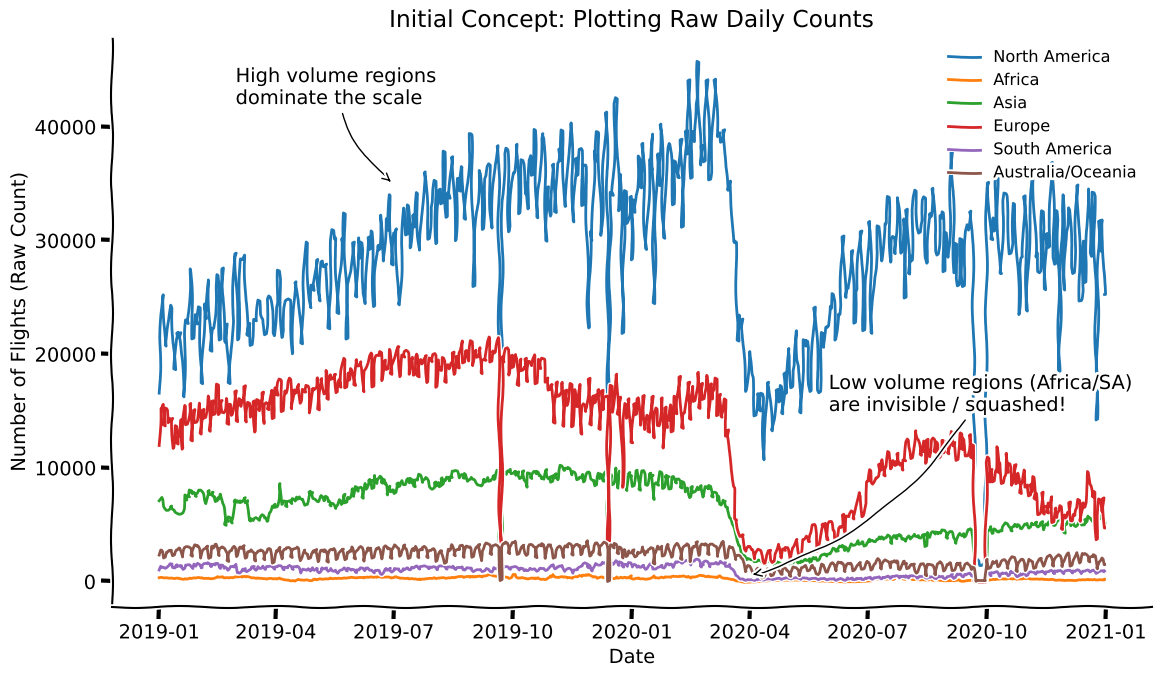

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/DCU/Data_Viz/daily_flight_counts_V3.csv')


# Convert 'day' to datetime objects for proper plotting
df['day'] = pd.to_datetime(df['day'])

# Sort by date to ensure the lines don't zig-zag
df = df.sort_values('day')

# Create the "Sketch" style plot
# The 'with plt.xkcd():' block applies the hand-drawn effect
with plt.xkcd():
    fig, ax = plt.subplots(figsize=(12, 7))

    # Loop through each region and plot its line
    regions = df['region'].unique()

    for region in regions:
        region_data = df[df['region'] == region]
        ax.plot(region_data['day'], region_data['flight_count'], label=region)

    # Point out the scale dominance
    # (Pointing roughly to North America/Europe levels in mid-2019)
    ax.annotate(
        'High volume regions\ndominate the scale',
        xy=(pd.to_datetime('2019-07-01'), 35000),
        xytext=(pd.to_datetime('2019-03-01'), 42000),
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2', color='black')
    )

    # Point out the "Squashed" problem at the bottom
    # (Pointing to the cluttered bottom area where Africa/SA are flat)
    ax.annotate(
        'Low volume regions (Africa/SA)\nare invisible / squashed!',
        xy=(pd.to_datetime('2020-04-01'), 500),
        xytext=(pd.to_datetime('2020-06-01'), 15000),
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-.2', color='black')
    )

    ax.set_title("Initial Concept: Plotting Raw Daily Counts")
    ax.set_ylabel("Number of Flights (Raw Count)")
    ax.set_xlabel("Date")

    # Simple legend
    ax.legend(loc='upper right', frameon=False, fontsize='small')

    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')

    plt.tight_layout()

    plt.savefig('figure1_sketch.png', dpi=100)
    plt.show()